In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from typing import TypedDict, Annotated, Optional, List, Literal
from langgraph.graph import StateGraph, add_messages, START, END 
import requests
from bs4 import BeautifulSoup
from langgraph.types import Command
from langchain_core.messages import HumanMessage, AIMessage 
from pydantic import BaseModel, Field, field_validator, AliasChoices
from IPython.display import Image, display 

In [2]:
load_dotenv()

True

In [9]:
import requests
from bs4 import BeautifulSoup

def fetch_job_content(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    # Remove scripts/styles (noise)
    for tag in soup(["script", "style", "noscript"]):
        tag.extract()

    # Get clean text
    text = soup.get_text(separator="\n")

    # Optional: clean extra whitespace
    lines = [line.strip() for line in text.splitlines() if line.strip()]

    return "\n".join(lines)

# Example
url = "https://reliefweb.int/job/4211604/monitoring-and-evaluation-assistant-digital-learning-programme"
content = fetch_job_content(url)

print(content)  # preview

In [10]:
content

''

In [6]:
model = ChatGroq(model="llama-3.1-8b-instant")

url = "https://reliefweb.int/job/4211604/monitoring-and-evaluation-assistant-digital-learning-programme"

In [7]:
ad_content = load_ad_page(url)

print(ad_content)

--- Loaded page with 0 words ---



In [11]:
import requests
from bs4 import BeautifulSoup

url = "https://reliefweb.int/job/4211577/enumerators-strides-baseline-study"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)
response.raise_for_status()

# Parse HTML
soup = BeautifulSoup(response.text, "html.parser")

# Remove scripts/styles/navigation junk
for tag in soup(["script", "style", "noscript", "header", "footer", "nav", "aside"]):
    tag.decompose()

# Extract clean visible text
text = soup.get_text(separator="\n")

# Clean empty lines
lines = [line.strip() for line in text.splitlines()]
clean_text = "\n".join(line for line in lines if line)

print(clean_text)

In [12]:
import requests
from bs4 import BeautifulSoup


def read_webpage(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    # Remove unnecessary elements
    for tag in soup([
        "script",
        "style",
        "noscript",
        "header",
        "footer",
        "nav",
        "aside"
    ]):
        tag.decompose()

    # Extract readable text
    text = soup.get_text(separator="\n")

    # Clean empty lines
    lines = [line.strip() for line in text.splitlines()]
    clean_text = "\n".join(line for line in lines if line)

    return clean_text


# Example usage
content = read_webpage("https://reliefweb.int/job/4211577/enumerators-strides-baseline-study")
print(content)

In [13]:
!pip install selenium beautifulsoup4

     ---------------------------------------- 9.7/9.7 MB 6.9 MB/s eta 0:00:00
     -------------------------------------- 510.3/510.3 kB 8.1 MB/s eta 0:00:00
  Using cached websocket_client-1.9.0-py3-none-any.whl (82 kB)
  Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
  Using cached cffi-2.0.0-cp311-cp311-win_amd64.whl (182 kB)
  Using cached pycparser-3.0-py3-none-any.whl (48 kB)



[notice] A new release of pip available: 22.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup


def read_dynamic_webpage(url):
    options = Options()
    options.add_argument("--headless")

    driver = webdriver.Chrome(options=options)

    driver.get(url)

    html = driver.page_source

    driver.quit()

    soup = BeautifulSoup(html, "html.parser")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    return soup.get_text(separator="\n", strip=True)


content = read_dynamic_webpage("https://reliefweb.int/job/4211577/enumerators-strides-baseline-study")

print(content[:5000])

403 Forbidden
403 Forbidden


In [15]:
import requests
from bs4 import BeautifulSoup


def read_webpage(url):
    headers = {
        "User-Agent": "Mozilla/5.0"
    }

    response = requests.get(url, headers=headers)
    response.raise_for_status()

    soup = BeautifulSoup(response.text, "html.parser")

    # Remove unwanted tags
    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    # Try to get main body content
    body = soup.body

    if body:
        text = body.get_text(separator="\n", strip=True)
    else:
        text = soup.get_text(separator="\n", strip=True)

    return text


# Example
url = "https://reliefweb.int/job/4211577/enumerators-strides-baseline-study"

content = read_webpage(url)

print(content[:5000])  # print first 5000 chars

In [16]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup
import time


def read_webpage(url):
    options = Options()
    options.add_argument("--headless=new")
    options.add_argument("--disable-gpu")
    options.add_argument("--no-sandbox")

    driver = webdriver.Chrome(options=options)

    try:
        driver.get(url)

        # wait for page body to load
        WebDriverWait(driver, 15).until(
            EC.presence_of_element_located((By.TAG_NAME, "body"))
        )

        # extra wait for JS-rendered content
        time.sleep(5)

        html = driver.page_source

    finally:
        driver.quit()

    soup = BeautifulSoup(html, "html.parser")

    # remove junk
    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    text = soup.get_text(separator="\n")

    # clean lines
    lines = [line.strip() for line in text.splitlines()]
    clean_text = "\n".join(line for line in lines if line)

    return clean_text


content = read_webpage("https://reliefweb.int/job/4211577/enumerators-strides-baseline-study")

print(content[:10000])

403 Forbidden
403 Forbidden


In [34]:
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from bs4 import BeautifulSoup
import time


def read_webpage(url):
    options = Options()

    # makes browser look more real
    options.add_argument("--disable-blink-features=AutomationControlled")
    options.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) "
        "Chrome/124.0.0.0 Safari/537.36"
    )

    # comment this out if blocked
    # options.add_argument("--headless=new")

    driver = webdriver.Chrome(options=options)

    # hide selenium traces
    driver.execute_script("""
        Object.defineProperty(navigator, 'webdriver', {
            get: () => undefined
        })
    """)

    driver.get(url)

    # wait for JS content
    time.sleep(5)

    html = driver.page_source

    driver.quit()

    soup = BeautifulSoup(html, "html.parser")

    for tag in soup(["script", "style", "noscript"]):
        tag.decompose()

    text = soup.get_text(separator="\n", strip=True)

    return text


content = read_webpage("https://www.myjobmag.co.ke/job/direct-sales-agent-nyahururu-experience-in-fixed-internet-is-an-added-advantage-hcs-affiliates-group")

print(content)

Direct Sales Agent - Nyahururu (Experience in Fixed Internet is an Added Advantage) at HCS Affiliates Group May, 2026 |  MyJobMag
X
Employers, Post a Job
Jobs
Jobs by Field
Jobs by Location
Jobs by Education
Jobs by Industry
Remote Jobs
Get Advice
Career Advice
HR/Recruiter Advice
Scholarships
Post Jobs
Post A Job / Recruit
Login
Signup
Login
Signup
Employers
Kenya
Ghana
Kenya
Nigeria
South Africa
UK
Jobs
Career Advice
Post Job
Search for Jobs
Nairobi
Mombasa
Baringo
Bomet
Bungoma
Busia
Chuka
Eldoret
Elgeyo Marakwet
Embu
Garissa
Homa Bay
Isiolo
Kajiado
Kakamega
Karatina
Kericho
Kerugoya
Kiambu
Kilifi
Kirinyaga
Kisii
Kisumu
Kitale
Kitengela
Kitui
Kwale
Laikipia
Lamu
Machakos
Makueni
Mandera
Marsabit
Meru
Migori
Muranga
Nakuru
Nandi
Nanyuki
Narok
Nyamira
Nyandarua
Nyeri
Samburu
Siaya
Taita Taveta
Tana River
Tharaka Nithi
Thika
Trans Nzoia
Turkana
Uasin Gishu
Vihiga
Wajir
West Pokot
Administration / Facilities
Agriculture / Agro-Allied
Art / Crafts / Languages
Aviation / Aerospace
Banking

In [23]:
content

'Direct Sales Agent - Nyahururu (Experience in Fixed Internet is an Added Advantage) at HCS Affiliates Group May, 2026 |  MyJobMag\nX\nEmployers, Post a Job\nJobs\nJobs by Field\nJobs by Location\nJobs by Education\nJobs by Industry\nRemote Jobs\nGet Advice\nCareer Advice\nHR/Recruiter Advice\nScholarships\nPost Jobs\nPost A Job / Recruit\nLogin\nSignup\nLogin\nSignup\nEmployers\nKenya\nGhana\nKenya\nNigeria\nSouth Africa\nUK\nJobs\nCareer Advice\nPost Job\nSearch for Jobs\nNairobi\nMombasa\nBaringo\nBomet\nBungoma\nBusia\nChuka\nEldoret\nElgeyo Marakwet\nEmbu\nGarissa\nHoma Bay\nIsiolo\nKajiado\nKakamega\nKaratina\nKericho\nKerugoya\nKiambu\nKilifi\nKirinyaga\nKisii\nKisumu\nKitale\nKitengela\nKitui\nKwale\nLaikipia\nLamu\nMachakos\nMakueni\nMandera\nMarsabit\nMeru\nMigori\nMuranga\nNakuru\nNandi\nNanyuki\nNarok\nNyamira\nNyandarua\nNyeri\nSamburu\nSiaya\nTaita Taveta\nTana River\nTharaka Nithi\nThika\nTrans Nzoia\nTurkana\nUasin Gishu\nVihiga\nWajir\nWest Pokot\nAdministration / Faci

In [24]:
def is_job_advertisement_node(content):
    prompt = f"""
You are a classifier.

Determine whether the following webpage content is a job advertisement/posting.

Respond ONLY with:
YES
or
NO

Webpage content:
{content}
"""

    response = model.invoke([
        HumanMessage(content=prompt)
    ])

    return response.content.strip()

result = is_job_advertisement_node(content)
print(result)


## Cover Letter Builder
def cover_letter_builder_node():
    "Build the cover letter"

def resume_builder_node():
    "Build the resume"

YES


In [31]:
from langgraph.graph import MessagesState

graph = StateGraph(MessagesState)

graph.add_node("Check Advertisment", is_job_advertisement_node)
graph.add_node("Cover Letter Generator", cover_letter_builder_node)
graph.add_node("Resume Builder", resume_builder_node)

graph.add_edge("Check Advertisment", "Cover Letter Generator")
graph.add_edge("Check Advertisment", "Resume Builder")
graph.set_entry_point("Check Advertisment")

app=graph.compile()

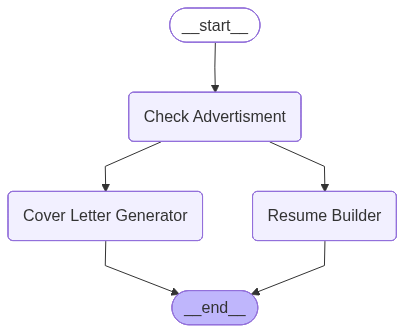

In [32]:
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

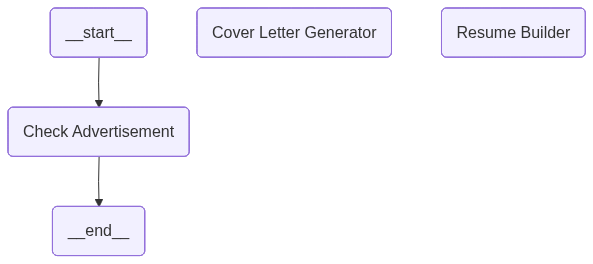

In [35]:
def is_job_advertisement_node(content):
    prompt = f"""
You are a classifier.

Determine whether the following webpage content is a job advertisement/posting.

Respond ONLY with:
YES
or
NO

Webpage content:
{content}
"""

    response = model.invoke([
        HumanMessage(content=prompt)
    ])

    answer = response.content.strip().upper()

    return {
        "job_advertisement": answer
    }


## Cover Letter Builder
def cover_letter_builder_node(state: MessagesState):
    print("Building the Cover Letter")

    return{
        "cover letter": "Generated Cover Letter"
    }


def resume_builder_node(state: MessagesState):
    print("Building Resume")

    return {
        "resume": "Generated Resume"
    }

def advertisement_router(state: MessagesState):
    if state["job_advertisement"] == "YES":
        return [
            "Cover Letter Generator",
            "Resume Builder"
        ]
    
    return END



## Building the Graph Structure
graph = StateGraph(MessagesState)

graph.add_node("Check Advertisement", is_job_advertisement_node)
graph.add_node("Cover Letter Generator", cover_letter_builder_node)
graph.add_node("Resume Builder", resume_builder_node)

graph.add_conditional_edges("Check Advertisement", advertisement_router)

graph.set_entry_point("Check Advertisement")

graph.add_edge("Cover Letter Generator", END)
graph.add_edge("Resume Builder", END)

app = graph.compile()

display(Image(app.get_graph(xray=True).draw_mermaid_png()))